## Set Up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
import sys
import os

In [2]:
#use Path to get current directory of this notebook
current_dir = Path().resolve()
ROOT_DIR = str(current_dir / '../../')
sys.path.append(ROOT_DIR)
sys.path.append(ROOT_DIR+'src/')

In [3]:
#local imports
import src.generic_analysis_utils as analysis_utils

In [4]:
scenarios_path = Path(ROOT_DIR) / "scenarios_inputs" / "nie/"
annotated_output_path = Path(ROOT_DIR) / "annotated_outputs" / "nie" / "archived_nie" 
plots_output_path = Path(ROOT_DIR) / "analysis/" / "nie" / "plots/"

In [5]:
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

scenarios_path: /Users/anna/Documents/code/graph_extract/analysis/nie/../../scenarios_inputs/nie
annotated_output_path: /Users/anna/Documents/code/graph_extract/analysis/nie/../../annotated_outputs/nie/archived_nie


In [6]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

## Define Functions

In [7]:
def read_scenario(i): 

    file_path = annotated_output_path / f"nie_scenarios_{i}_choice_1.json"

    nodes =    analysis_utils.read_annotation(file_path)

    scenario_text = analysis_utils.read_input_scenario(scenarios_path / "nie_scenarios.json", i)


    return nodes, scenario_text

## Read in Scenarios

In [9]:
with open(scenarios_path / "nie_scenarios.json") as f:
    SCENARIO_LIST = json.load(f)

SCENARIO_ID_LIST = [scenario["id"] for scenario in SCENARIO_LIST]



## Causality and Intentionality

In [13]:
#create CIK dataframe
cik_df_all = pd.DataFrame()

#for each scenario ID that we have annotations for -- 
for i in SCENARIO_ID_LIST:  
    
    this_scenario = [scenario_dict for scenario_dict in SCENARIO_LIST if scenario_dict["id"] == i]  #get the scenario with this id

    scenario_factors = this_scenario[0]["factors"]['1'] #scenario experimentor labels for choice 1


    if "Causal Role" in scenario_factors.keys(): #check that it has the relevant factor Causal Role
        
        #read this annotation
        nodes = analysis_utils.read_annotation(annotated_output_path / f"nie_scenarios_{i}_choice_1.json")
        #extract the CIK links
        cik_df = analysis_utils.get_cik_links(nodes).sort_values('event')
        #extract utilities                
        util_df= analysis_utils.events_to_utility_df(nodes)

        #get mean util per event
        mean_utils = util_df.mean(axis=1)
        mean_utils_df = pd.DataFrame(mean_utils)
        mean_utils_df = mean_utils_df.reset_index()
        mean_utils_df.columns = ['event', 'mean_utility']

        #sort both dfs by event column so we can merge them

        cik_df = cik_df.sort_values("event").reset_index(drop=True)
        mean_utils_df = mean_utils_df.sort_values("event").reset_index(drop=True)
        assert cik_df["event"].tolist() == mean_utils_df["event"].tolist()

        cik_df['utils'] = mean_utils_df['mean_utility']

        #convert to 0 or 1 numeric for +  / -
        cik_df['C'] = cik_df['C'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))
        cik_df['I'] = cik_df['I'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))
        cik_df['K'] = cik_df['K'].apply(lambda x: 1 if x == '+' else (0 if x == '-' else x))

        #create a df with the scenario labels
        cik_df['SID'] = i
        cik_df['Causal Role'] = scenario_factors["Causal Role"]
        cik_df['Beneficiary'] = scenario_factors["Beneficiary"]
        cik_df['Evitability'] = scenario_factors["Evitability"]
        cik_df['Personal Force'] = scenario_factors["Personal Force"]
        
        cik_df_all = pd.concat([cik_df_all, cik_df], ignore_index=True)


In [24]:
cik_df_all

,event,C,I,K,utils,SID,Causal Role,Beneficiary,Evitability,Personal Force
0,I push the heavy worker from the bridge,1,1,1,-23.333333,10,Means,Other-beneficial,Avoidable,Personal
1,The heavy worker dies,1,1,1,-28.333333,10,Means,Other-beneficial,Avoidable,Personal
2,The heavy worker is struck by the speed-train,1,1,1,-36.666667,10,Means,Other-beneficial,Avoidable,Personal
3,The speed-train stops,1,1,1,-26.666667,10,Means,Other-beneficial,Avoidable,Personal
4,The three railroad workers are not run over,1,1,1,0.000000,10,Means,Other-beneficial,Avoidable,Personal
...,...,...,...,...,...,...,...,...,...,...
304,My soldiers witness the spy's suffering.,1,0,1,-25.000000,61,Means,Other-beneficial,Inevitable,Impersonal
305,The rats are able to feed on the spy's body,1,0,1,-18.333333,61,Means,Other-beneficial,Inevitable,Impersonal
306,The spy experiences increased physical pain an...,1,1,1,-17.500000,61,Means,Other-beneficial,Inevitable,Impersonal
307,The spy may die from his injuries and rat bites,1,0,1,-51.666667,61,Means,Other-beneficial,Inevitable,Impersonal


In [25]:
sid_agg_df = (
    cik_df_all
    .groupby("SID", as_index=False)
    .agg(
        n_events=("event", "count"),
        C_mean=("C", "mean"),
        I_mean=("I", "mean"),
        K_mean=("K", "mean"),
        utils_mean=("utils", "mean"),
        utils_sum=("utils", "sum"),
        Causal_Role=("Causal Role", "first"),
        Beneficiary=("Beneficiary", "first"),
        Evitability=("Evitability", "first"),
        Personal_Force=("Personal Force", "first"),
    )
    .sort_values("SID")
)

sid_agg_df

,SID,n_events,C_mean,I_mean,K_mean,utils_mean,utils_sum,Causal_Role,Beneficiary,Evitability,Personal_Force
0,10,6,1.000000,1.000000,1.000000,-19.166667,-115.000000,Means,Other-beneficial,Avoidable,Personal
1,11,7,1.000000,1.000000,1.000000,-4.285714,-30.000000,Means,Other-beneficial,Avoidable,Impersonal
2,16,7,1.000000,1.000000,0.857143,-13.571429,-95.000000,Means,Self-beneficial,Avoidable,Personal
3,17,8,0.750000,0.625000,0.500000,-26.875000,-215.000000,Side Effect,Self-beneficial,Avoidable,Impersonal
4,18,4,1.000000,1.000000,0.750000,-7.187500,-28.750000,Side Effect,Self-beneficial,Avoidable,Personal
5,19,8,1.000000,1.000000,1.000000,-6.718750,-53.750000,Side Effect,Self-beneficial,Avoidable,Impersonal
6,20,6,1.000000,1.000000,0.833333,13.888889,83.333333,Side Effect,Self-beneficial,Avoidable,Personal
7,21,4,1.000000,1.000000,1.000000,-18.333333,-73.333333,Side Effect,Self-beneficial,Avoidable,Impersonal
8,22,6,1.000000,1.000000,1.000000,-9.375000,-56.250000,Means,Self-beneficial,Avoidable,Personal
9,23,4,1.000000,1.000000,0.750000,-12.812500,-51.250000,Means,Self-beneficial,Avoidable,Impersonal


In [28]:
# Create summary table of C, I, K values for the Causal Role and Evitability factors 
summary_CIK_df = sid_agg_df.groupby(["Causal_Role", "Evitability"])[["I_mean"]].agg(['mean', 'sem']).reset_index()
print("\nSummary Table of C, I, K values by Causal Role and Evitability:")
print(summary_CIK_df.to_string())


Summary Table of C, I, K values by Causal Role and Evitability:
   Causal_Role Evitability    I_mean          
                                mean       sem
0        Means   Avoidable  0.822487  0.065194
1        Means  Inevitable  0.732226  0.049447
2  Side Effect   Avoidable  0.733413  0.074879
3  Side Effect  Inevitable  0.772619  0.050941


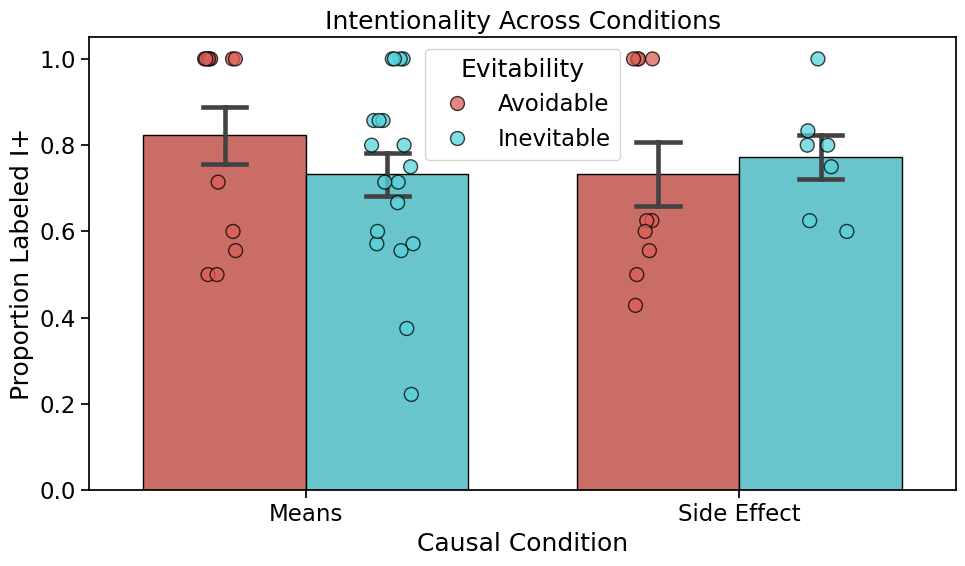

In [30]:
analysis_utils.plot_bar_strip(df = sid_agg_df, x = "Causal_Role", y = "I_mean", hue= "Evitability",title = "Intentionality Across Conditions",xlabel = 'Causal Condition', ylabel = 'Proportion Labeled I+')

## Deontology

In [58]:

deont_df_all = pd.DataFrame()

#for each scenario ID that we have annotations for -- 
for i in SCENARIO_ID_LIST:  
    
    this_scenario = [scenario_dict for scenario_dict in SCENARIO_LIST if scenario_dict["id"] == i]  #get the scenario with this id

    scenario_factors = this_scenario[0]["factors"]['1'] #scenario experimentor labels for choice 1


    if "Personal Force" in scenario_factors.keys(): #check that it has the relevant factor Personal Force

         #read this annotation
        nodes = analysis_utils.read_annotation(annotated_output_path / f"nie_scenarios_{i}_choice_1.json")
        #extract deontology
        deont_value = analysis_utils.extract_deontology(nodes)
        deont_value = float(deont_value)
       
       #create dataframe
        deont_df = pd.DataFrame({
            "SID": i,
            "Personal Force": scenario_factors['Personal Force'],
            "Annotator Rating": deont_value
        }, index = [0])
        # deont_df = pd.DataFrame({
            # "SID": i,
            # "Personal Force": scenario_factors['Personal Force'],
            # "Annotator Rating": deont_value
        # })
       
        deont_df_all = pd.concat([deont_df_all, deont_df])

/Users/anna/Documents/code/graph_extract/analysis/nie/../../src/generic_analysis_utils.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  """parse the read in filenames to get the condition and id
/Users/anna/Documents/code/graph_extract/analysis/nie/../../src/generic_analysis_utils.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  assuming filename is of the form "%s_%d_choice_1.json"""


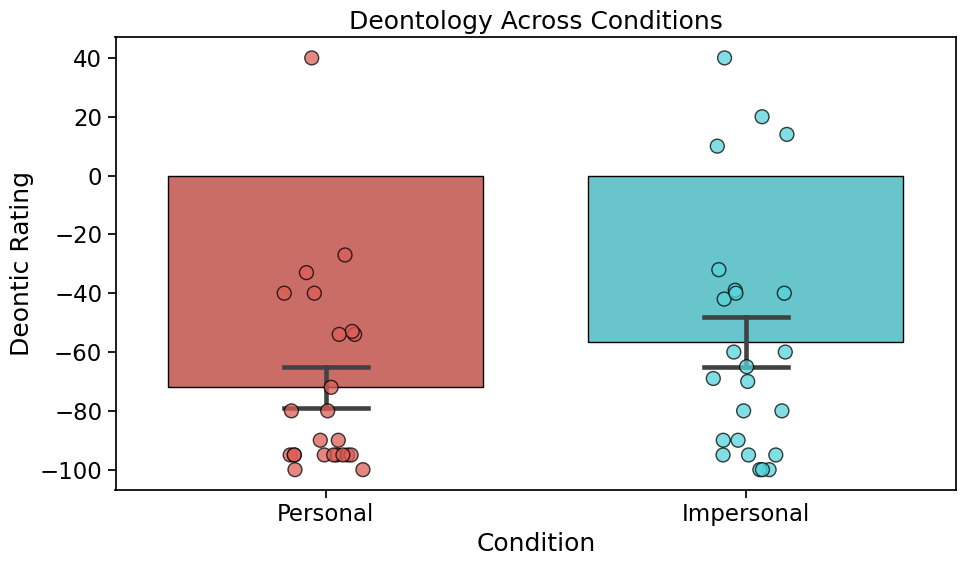

In [62]:
analysis_utils.plot_bar_strip(df = deont_df_all, x = "Personal Force", y = "Annotator Rating", title = "Deontology Across Conditions",xlabel = 'Condition', ylabel = 'Deontic Rating')

In [63]:
deont_summary_df = (
    deont_df_all
    .groupby("Personal Force", as_index=False)["Annotator Rating"]
    .agg(mean="mean", se="sem")
)

print(deont_summary_df.to_string(index=False))

Personal Force       mean       se
    Impersonal -56.583333 8.525944
      Personal -72.000000 6.896229


In [65]:
personal_ratings = deont_df_all[deont_df_all['Personal Force'] == 'Personal']['Annotator Rating']
impersonal_ratings = deont_df_all[deont_df_all['Personal Force'] == 'Impersonal']['Annotator Rating']

t_stat, p_value = ttest_ind(personal_ratings, impersonal_ratings)

print(f"\nt-test results:")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")


t-test results:
t-statistic: -1.406
p-value: 0.1665
